In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import openpyxl

# Road Traffic Crash Analysis in Nigeria (2021–2023)

Road traffic crashes remain a major public safety and public health concern in Nigeria, contributing significantly to fatalities, injuries, and economic losses. Understanding the temporal, spatial, and causal patterns of road traffic crashes is essential for evidence-based policy formulation and effective road safety interventions.

This study analyzes road traffic crash data in Nigeria from 2021 to 2023 with the aim of identifying:
- Trends in crash occurrences over time
- High-risk states (crash hotspots)
- Dominant crash causes
- Vehicle categories most involved in crashes
- Gender distribution of injuries and fatalities

The analysis was conducted using Python, leveraging libraries such as Pandas, Matplotlib, and GeoPandas for data processing, visualization, and geospatial analysis.


In [2]:
# Data Import
df = pd.read_excel(
   "Road_Transport_Data.xlsx", sheet_name=None
)

print(df.keys())

dict_keys(['RoadCrashesmain', 'RoadCrashes21Q1', 'RoadCrashes21Q2', 'RoadCrashes21Q3', 'RoadCrashes21Q4', 'RoadCrashes22Q1', 'RoadCrashes22Q2', 'RoadCrashes22Q3', 'RoadCrashes22Q4', 'RoadCrashes23Q1', 'RoadCrashes23Q2', 'RoadCrashes23Q3', 'RoadCrashes23Q4', 'InjGender21', 'InjGender22', 'InjGender23', 'KillGend2021', 'KillGend2022', 'KillGend2023', 'VehNum2021', 'VehNum2022', 'VehNum2023', 'VehCat2021', 'VehCat2022', 'VehCat2023', 'CrashCaus21Q1', 'CrashCaus21Q2', 'CrashCaus21Q3', 'CrashCaus21Q4', 'CrashCaus22Q1', 'CrashCaus22Q2', 'CrashCaus22Q3', 'CrashCaus22Q4', 'CrashCaus23Q1', 'CrashCaus23Q2', 'CrashCaus23Q3', 'CrashCaus23Q4', 'CausFacCode'])


## Data Description

The dataset used in this analysis was obtained from official road traffic crash records covering the period from 2021 to 2023. The data is organized across multiple Excel sheets, each representing different aspects of road traffic crashes.

Key data components include:
- **RoadCrashes** sheets: Total crash cases by state and quarter
- **CrashCaus** sheets: Crash occurrences categorized by cause
- **VehCat / VehNum** sheets: Vehicle categories and types involved in crashes
- **InjGender / KillGend** sheets: Gender distribution of injuries and fatalities

Each year is divided into four quarters (Q1–Q4), allowing for temporal analysis at a quarterly resolution.


In [3]:
# Inspecting missing value 
exclude_sheets = ["RoadCrashesmain", "CausFacCode"]

for name, d in df.items():
    if name in exclude_sheets:
        continue
        
    print(f"\n{name}")
    print(d.isna().sum())



RoadCrashes21Q1
STATE              0
FATAL              0
SERIOUS            0
MINOR              0
TOTAL CASES        0
NUMBER INJURED     0
NUMBER KILLED      0
TOTAL CASUALTY     0
PEOPLE INVOLVED    0
QUARTERS_21        0
dtype: int64

RoadCrashes21Q2
STATE              0
FATAL              0
SERIOUS            0
MINOR              0
TOTAL CASES        0
NUMBER INJURED     0
NUMBER KILLED      0
TOTAL CASUALTY     0
PEOPLE INVOLVED    0
QUARTERS_21        0
dtype: int64

RoadCrashes21Q3
STATE              0
FATAL              0
SERIOUS            0
MINOR              0
TOTAL CASES        0
NUMBER INJURED     0
NUMBER KILLED      0
TOTAL CASUALTY     0
PEOPLE INVOLVED    0
QUARTERS_21        0
dtype: int64

RoadCrashes21Q4
STATE              0
FATAL              0
SERIOUS            0
MINOR              0
TOTAL CASES        0
NUMBER INJURED     0
NUMBER KILLED      0
TOTAL CASUALTY     0
PEOPLE INVOLVED    0
QUARTERS_21        0
dtype: int64

RoadCrashes22Q1
STATE              0
FA

## Data Preparation and Cleaning

Prior to analysis, several data cleaning and preprocessing steps were performed to ensure accuracy and consistency:

1. **Removal of aggregate rows**  
   Rows labeled as *TOTAL* were removed to prevent double counting during aggregation.

2. **Standardization of state names**  
   State names were standardized to ensure consistency across datasets, particularly for the Federal Capital Territory (FCT), which appears under different a label as *FCT*.

3. **Aggregation across quarters and years**  
   Quarterly data were aggregated to compute total crash counts per state, vehicle category, crash cause, and gender for the full study period (2021–2023).

These steps ensured reliable comparisons across time and spatial units.


In [4]:
#How have road traffic crash occurrences changed across quarters from 2021 to 2023 in Nigeria?
# Load all sheets into a dictionary
df_dict = pd.read_excel(
   "Road_Transport_Data.xlsx", sheet_name=None
)

results = {}

for sheet, df in df_dict.items():
    if sheet.startswith("RoadCrashes") and sheet != "RoadCrashesmain":
        
        # Remove TOTAL row to avoid double counting
        df = df[df["STATE"].str.upper() != "TOTAL"]
        
        # Sum TOTAL CASES
        results[sheet] = df["TOTAL CASES"].sum()

# Display results
for sheet, total in results.items():
    print(f"{sheet}: {total}")


RoadCrashes21Q1: 3301
RoadCrashes21Q2: 3185
RoadCrashes21Q3: 3134
RoadCrashes21Q4: 3407
RoadCrashes22Q1: 3345
RoadCrashes22Q2: 3282
RoadCrashes22Q3: 3412
RoadCrashes22Q4: 3617
RoadCrashes23Q1: 2733
RoadCrashes23Q2: 2967
RoadCrashes23Q3: 2187
RoadCrashes23Q4: 2717


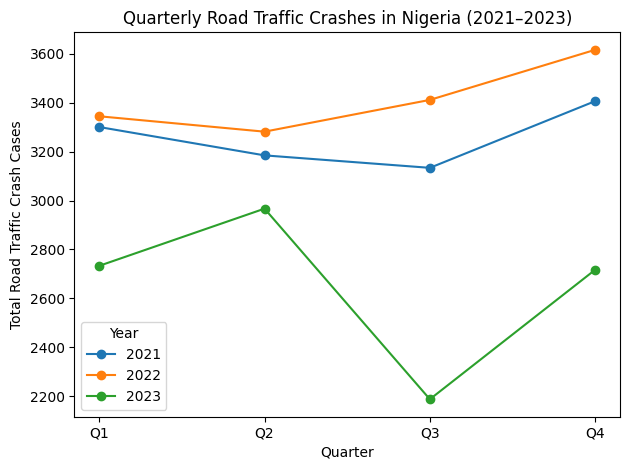

In [5]:
# Visual presentation of road traffic crash occurrences across quarters from 2021 to 2023 in Nigeria
# Collect data
records = []

for sheet, df in df_dict.items():
    if sheet.startswith("RoadCrashes") and sheet != "RoadCrashesmain":
        df = df[df["STATE"].str.upper() != "TOTAL"]
        total_cases = df["TOTAL CASES"].sum()

        year = sheet[11:13]     # 21, 22, 23
        quarter = sheet[-2:]    # Q1, Q2, Q3, Q4

        records.append([year, quarter, total_cases])

trend_df = pd.DataFrame(records, columns=["Year", "Quarter", "Total Cases"])

# Plot one chart per year
plt.figure()

for year in ["21", "22", "23"]:
    year_df = (
        trend_df[trend_df["Year"] == year]
        .sort_values("Quarter")
    )
    
    plt.plot(
        year_df["Quarter"],
        year_df["Total Cases"],
        marker="o",
        label=f"20{year}"
    )

plt.xlabel("Quarter")
plt.ylabel("Total Road Traffic Crash Cases")
plt.title("Quarterly Road Traffic Crashes in Nigeria (2021–2023)")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [6]:
#How have road traffic casualties occurrences changed across quarters from 2021 to 2023 in Nigeria?
results = {}

for sheet, df in df_dict.items():
    if sheet.startswith("RoadCrashes") and sheet != "RoadCrashesmain":
        
        # Remove TOTAL row to avoid double counting
        df = df[df["STATE"].str.upper() != "TOTAL"]
        
        # Sum TOTAL CASES
        results[sheet] = df["TOTAL CASUALTY"].sum()

# Display results
for sheet, total in results.items():
    print(f"{sheet}: {total}")

RoadCrashes21Q1: 11725
RoadCrashes21Q2: 10471
RoadCrashes21Q3: 10259
RoadCrashes21Q4: 11823
RoadCrashes22Q1: 12128
RoadCrashes22Q2: 10684
RoadCrashes22Q3: 10734
RoadCrashes22Q4: 11840
RoadCrashes23Q1: 9780
RoadCrashes23Q2: 9786
RoadCrashes23Q3: 6949
RoadCrashes23Q4: 10439


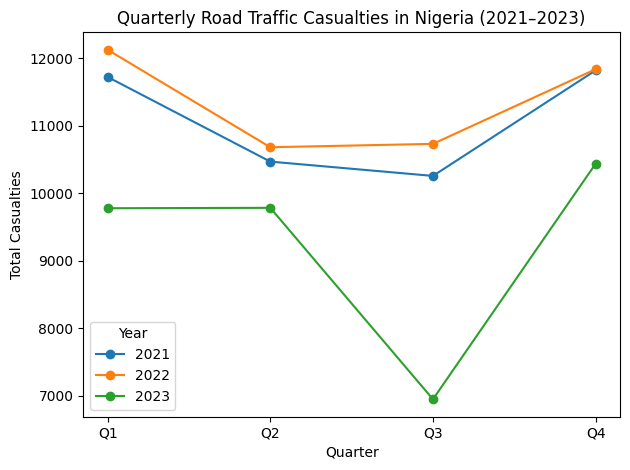

In [7]:
# Visual Presentation of road traffic casualties occurrences across quarters from 2021 to 2023 in Nigeria
# Collect data
records = []

for sheet, df in df_dict.items():
    if sheet.startswith("RoadCrashes") and sheet != "RoadCrashesmain":
        df = df[df["STATE"].str.upper() != "TOTAL"]
        total_cases = df["TOTAL CASUALTY"].sum()

        year = sheet[11:13]     # 21, 22, 23
        quarter = sheet[-2:]    # Q1, Q2, Q3, Q4

        records.append([year, quarter, total_cases])

trend_df = pd.DataFrame(records, columns=["Year", "Quarter", "TOTAL CASUALTY"])

# Plot one chart per year
plt.figure()

for year in ["21", "22", "23"]:
    year_df = (
        trend_df[trend_df["Year"] == year]
        .sort_values("Quarter")
    )

    plt.plot(
        year_df["Quarter"],
        year_df["TOTAL CASUALTY"],
        marker="o",
        label=f"20{year}"
    )

plt.xlabel("Quarter")
plt.ylabel("Total Casualties")
plt.title("Quarterly Road Traffic Casualties in Nigeria (2021–2023)")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [8]:
# Identify high-risk crash hotspot states

dfs = []

# Collect all RoadCrashes sheets
for sheet, df in df_dict.items():
    if sheet.startswith("RoadCrashes") and sheet != "RoadCrashesmain":
        
        # Remove TOTAL row
        df = df[df["STATE"].str.upper() != "TOTAL"]
        
        dfs.append(df[["STATE", "TOTAL CASES"]])

# Combine all years & quarters
combined_df = pd.concat(dfs, ignore_index=True)

# Aggregate total crashes per state
state_totals = (
    combined_df
    .groupby("STATE", as_index=False)["TOTAL CASES"]
    .sum()
    .sort_values("TOTAL CASES", ascending=False)
    .reset_index(drop=True)
)

state_totals

# Determine hotspot threshold
threshold = state_totals["TOTAL CASES"].quantile(0.75)

high_risk_states = state_totals[state_totals["TOTAL CASES"] >= threshold]

print(high_risk_states)


      STATE  TOTAL CASES
0       FCT         4267
1      Ogun         3301
2  Nasarawa         2577
3    Kaduna         2323
4       Oyo         1798
5     Lagos         1713
6     Niger         1671
7    Bauchi         1408
8      Kogi         1408
9      Ondo         1328


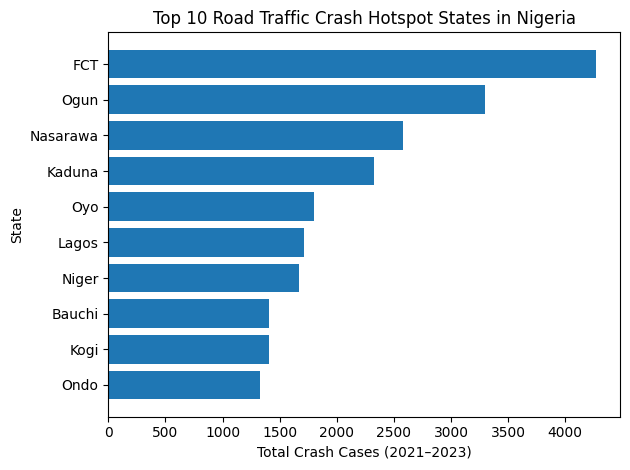

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(
    state_totals.head(10)["STATE"],
    state_totals.head(10)["TOTAL CASES"]
)
plt.xlabel("Total Crash Cases (2021–2023)")
plt.ylabel("State")
plt.title("Top 10 Road Traffic Crash Hotspot States in Nigeria")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Temporal Analysis of Road Traffic Crashes

To examine how road traffic crashes evolved over time, crash data were aggregated across all states for each quarter between 2021 and 2023.

The resulting time series provides insights into:
- Seasonal patterns in crash occurrences
- Periods of increased crash risk
- Long-term trends across the three-year period

This temporal analysis is useful for identifying peak risk periods that may require targeted road safety interventions.


In [10]:
import os

print(os.path.isdir("gadm41_NGA_1.json"))
print(os.listdir("gadm41_NGA_1.json"))

True
['gadm41_NGA_1.json']


In [11]:
import geopandas as gpd

states_map = gpd.read_file(r"gadm41_NGA_1.json\gadm41_NGA_1.json")
print(states_map.head())
print(states_map.columns)

     GID_1 GID_0  COUNTRY    NAME_1 VARNAME_1 NL_NAME_1 TYPE_1 ENGTYPE_1 CC_1  \
0  NGA.1_1   NGA  Nigeria      Abia        NA        NA  State     State   NA   
1  NGA.2_1   NGA  Nigeria   Adamawa        NA        NA  State     State   NA   
2  NGA.3_1   NGA  Nigeria  AkwaIbom        NA        NA  State     State   NA   
3  NGA.4_1   NGA  Nigeria   Anambra        NA        NA  State     State   NA   
4  NGA.5_1   NGA  Nigeria    Bauchi        NA        NA  State     State   NA   

  HASC_1  ISO_1                                           geometry  
0  NG.AB  NG-AB  MULTIPOLYGON (((7.4628 4.9818, 7.4626 4.9679, ...  
1  NG.AD  NG-AD  MULTIPOLYGON (((12.2507 8.1726, 12.2422 8.1647...  
2  NG.AK  NG-AK  MULTIPOLYGON (((8.3196 4.5576, 8.3179 4.559, 8...  
3  NG.AN  NG-AN  MULTIPOLYGON (((6.9358 5.858, 6.9363 5.8457, 6...  
4  NG.BA  NG-BA  MULTIPOLYGON (((9.7527 9.6009, 9.7354 9.5673, ...  
Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1

In [12]:
# NORMALIZE STATE NAMES (MATCH DASHBOARD LOGIC)

state_totals["STATE"] = (
    state_totals["STATE"]
    .astype(str)
    .str.strip()
    .str.lower()
)

state_totals["STATE"] = state_totals["STATE"].replace({
    "fct": "federalcapitalterritory",
    "federal capital territory": "federalcapitalterritory"
})

states_map["NAME_1"] = (
    states_map["NAME_1"]
    .astype(str)
    .str.strip()
    .str.lower()
)

geo_df = states_map.merge(
    state_totals,
    left_on="NAME_1",
    right_on="STATE",
    how="left"
)

geo_df["TOTAL CASES"] = geo_df["TOTAL CASES"].fillna(0)


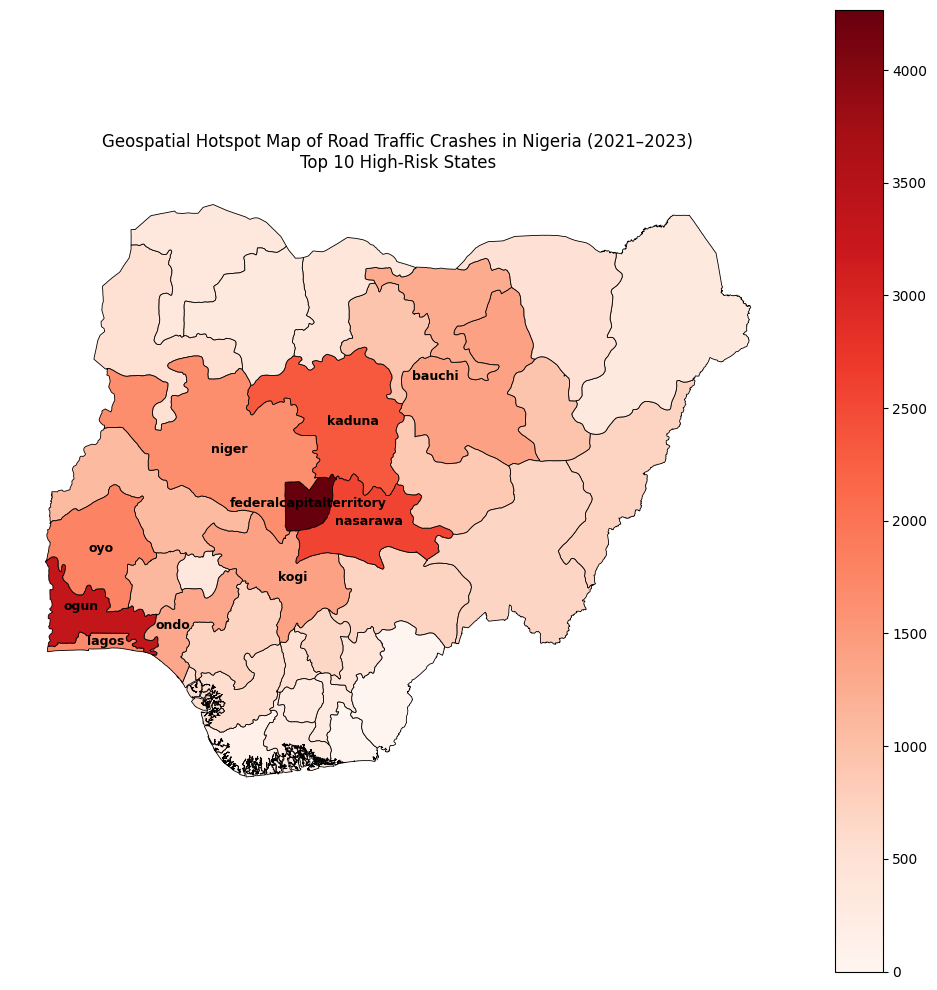

In [13]:
# Geospatial hotspot maps

top10_states = state_totals.head(10)["STATE"].tolist()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

geo_df.plot(
    column="TOTAL CASES",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Label top 10 hotspot states
for _, row in geo_df[geo_df["NAME_1"].isin(top10_states)].iterrows():
    point = row.geometry.representative_point()
    ax.text(
        point.x,
        point.y,
        row["NAME_1"],
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        color="black"
    )

ax.set_title(
    "Geospatial Hotspot Map of Road Traffic Crashes in Nigeria (2021–2023)\nTop 10 High-Risk States",
    fontsize=12
)

ax.axis("off")
plt.tight_layout()
plt.show()


## Geospatial Analysis of Crash Hotspots

Geospatial analysis was conducted to identify high-risk crash hotspot states in Nigeria. Total crash counts from 2021 to 2023 were spatially joined with administrative boundary data for Nigerian states.

Key objectives of this analysis include:
- Visual identification of states with consistently high crash occurrences
- Spatial comparison of crash intensity across the country
- Support for geographically targeted road safety interventions

To ensure accurate spatial matching, state names were normalized prior to merging crash data with geospatial boundary data. Representative points were used to label states on the map, ensuring visibility even for smaller regions such as the Federal Capital Territory (Abuja).


In [14]:

# Question: What are the leading causative factors of road traffic crashes in Nigeria?
# Hierarchical representation of crash causes from 2021 to 2023
dfs = []
for sheet, df in df_dict.items():
    if sheet.startswith("CrashCaus"):
        
        # Remove TOTAL row and Year_Total row if present
        df = df[~df["STATE"].astype(str).str.upper().isin(["TOTAL", "YEAR_TOTAL"])]
        
        # Drop non-cause columns
        df = df.drop(columns=["STATE", "TOTAL", "QUARTERS_21"], errors="ignore")
        
        dfs.append(df)

# Combine all years & quarters
combined_df = pd.concat(dfs, ignore_index=True)

# Sum numeric crash-cause columns
cause_totals = combined_df.sum(numeric_only=True)

# Convert to DataFrame and sort highest → lowest
cause_totals_df = (
    cause_totals
    .reset_index()
    .rename(columns={"index": "Crash Cause", 0: "Total Cases"})
    .sort_values(by="Total Cases", ascending=False)
    .reset_index(drop=True)
)

# Add ranking
cause_totals_df["Rank"] = cause_totals_df.index + 1

print(cause_totals_df)


   Crash Cause  Total Cases  Rank
0          SPV        26620     1
1          SLV         4012     2
2          WOT         2846     3
3          DGD         2772     4
4       OTHERS         2601     5
5          TBT         2354     6
6          RTV         2098     7
7          BFL         1863     8
8          MDV         1153     9
9          OBS          542    10
10         FTQ          477    11
11         OVL          430    12
12         BRD          261    13
13         DOT          157    14
14         SOS          142    15
15         DAD          103    16
16         UPD           98    17
17         PWR           33    18


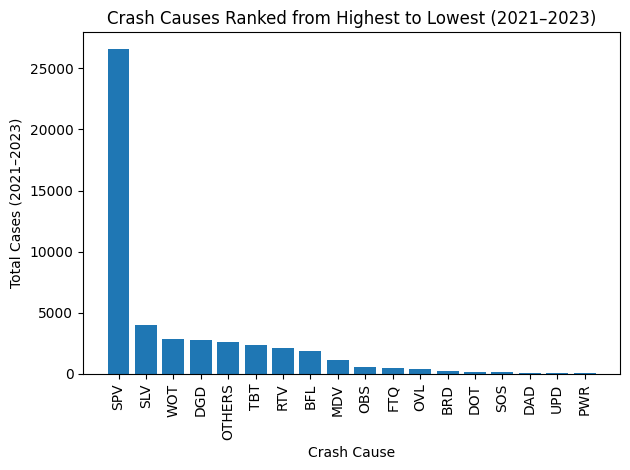

In [15]:
# Visual codes representing Crash Causes 
plt.figure()
plt.bar(cause_totals_df["Crash Cause"], cause_totals_df["Total Cases"])
plt.xticks(rotation=90)
plt.xlabel("Crash Cause")
plt.ylabel("Total Cases (2021–2023)")
plt.title("Crash Causes Ranked from Highest to Lowest (2021–2023)")
plt.tight_layout()
plt.show()


## Analysis of Crash Causes

Understanding the underlying causes of road traffic crashes is essential for designing preventive measures. Crash cause data were aggregated across all quarters and years to identify the most frequent contributing factors.

The analysis ranks crash causes from highest to lowest based on total isolations recorded. This allows for:
- Identification of dominant behavioral or mechanical risk factors
- Prioritization of enforcement and awareness campaigns
- Evidence-based road safety policymaking


            SEX  Year_Total  Rank
0    MALE ADULT       80198     1
1  FEMALE ADULT       22844     2
2    MALE CHILD        3138     3
3  FEMALE CHILD        2696     4


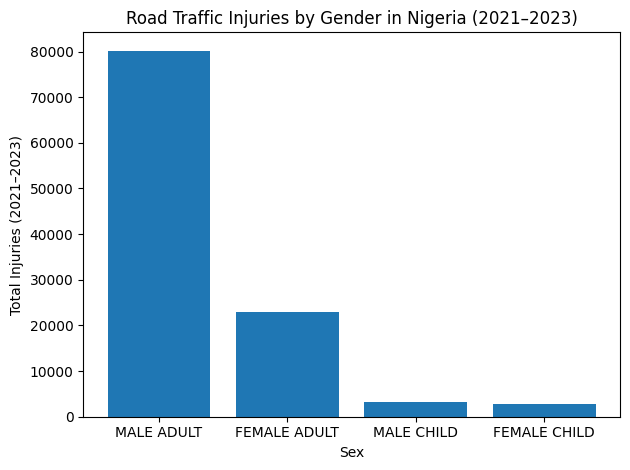

In [16]:
# How do road traffic casualties vary by sex and age group? 
# Road traffic injuries by Gender from 2021 to 2023
# Process InjGender sheets (2021–2023)
dfs = []
for sheet, df in df_dict.items():
    if sheet.startswith("InjGender"):
        
        # Remove TOTAL row and make a safe copy
        df = df[df["SEX"].str.upper() != "TOTAL"].copy()
        
        # Sum across quarterly columns for that year
        df.loc[:, "Year_Total"] = df.filter(like="NUMBER_INJURED").sum(axis=1)
        
        dfs.append(df[["SEX", "Year_Total"]])

# Combine all years
combined_df = pd.concat(dfs, ignore_index=True)

# Sum across all years by SEX and rank
gender_totals = (
    combined_df
    .groupby("SEX", as_index=False)["Year_Total"]
    .sum()
    .sort_values("Year_Total", ascending=False)
    .reset_index(drop=True)
)

# Add ranking column
gender_totals["Rank"] = gender_totals.index + 1

print(gender_totals)



#  Visual representation of Road Traffic Injuries 
plt.figure()
plt.bar(gender_totals["SEX"], gender_totals["Year_Total"])
plt.xlabel("Sex")
plt.ylabel("Total Injuries (2021–2023)")
plt.title("Road Traffic Injuries by Gender in Nigeria (2021–2023)")
plt.tight_layout()
plt.show()




            SEX  Year_Total  Rank
0    MALE ADULT       13754     1
1  FEMALE ADULT        2813     2
2    MALE CHILD         601     3
3  FEMALE CHILD         574     4


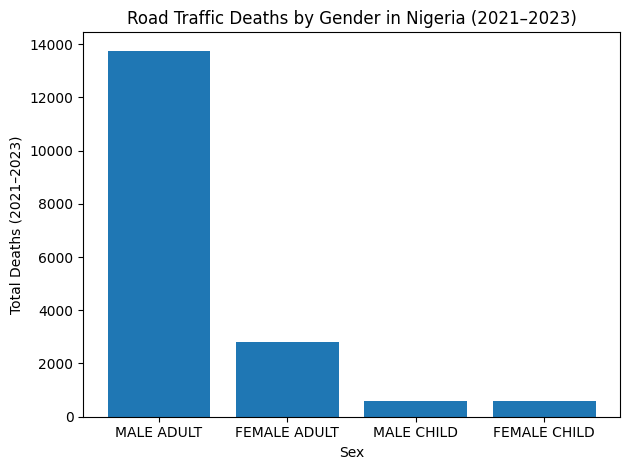

In [17]:
# Road traffic Deaths by Gender from 2021 to 2023
# Process KillGend sheets (2021–2023)
dfs = []
for sheet, df in df_dict.items():
    if sheet.startswith("KillGend"):
        
        # Remove TOTAL row and make a safe copy
        df = df[df["SEX"].str.upper() != "TOTAL"].copy()
        
        # Sum across quarterly columns for that year
        df.loc[:, "Year_Total"] = df.filter(like="NUMBER_KILLED").sum(axis=1)
        
        dfs.append(df[["SEX", "Year_Total"]])

# Combine all years
combined_df = pd.concat(dfs, ignore_index=True)

# Sum across all years by SEX and rank
gender_totals = (
    combined_df
    .groupby("SEX", as_index=False)["Year_Total"]
    .sum()
    .sort_values("Year_Total", ascending=False)
    .reset_index(drop=True)
)

# Add ranking column
gender_totals["Rank"] = gender_totals.index + 1

print(gender_totals)


#  Visual representation of Road Traffic Deaths
plt.figure()
plt.bar(gender_totals["SEX"], gender_totals["Year_Total"])
plt.xlabel("Sex")
plt.ylabel("Total Deaths (2021–2023)")
plt.title("Road Traffic Deaths by Gender in Nigeria (2021–2023)")
plt.tight_layout()
plt.show()


## Gender Distribution of Injuries and Fatalities

The demographic impact of road traffic crashes was assessed using gender-disaggregated data on injuries and fatalities.

The analysis examines:
- Differences in injury rates between males and females
- Gender disparities in crash-related fatalities
- Potential links to exposure patterns, driving behavior, and occupational risk

Gender-based insights are important for developing inclusive road safety policies and public health interventions.


In [18]:
# Which vehicle types contribute most to crash involvement in Nigeria?
# Vehicle types involved in Road Crashes from 2021 to 2023 across all quarters

# Clear the list at the start
dfs_num = []

for sheet, df in df_dict.items():
    if sheet.startswith("VehNum"):

        # Remove TOTAL row and make a copy
        df = df[df["VEHICLE CATEGORY"].astype(str).str.upper() != "TOTAL"].copy()

        # Select only numeric quarterly columns
        num_cols = df.filter(like="TYPE_NUM").columns
        df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

        # Sum quarterly columns for that year
        df["Year_Total"] = df[num_cols].sum(axis=1)

        # Keep only category and yearly total
        dfs_num.append(df[["VEHICLE CATEGORY", "Year_Total"]])

# Combine all years
combined_num_df = pd.concat(dfs_num, ignore_index=True)

# Sum across all years by vehicle category
vehicle_totals_num = (
    combined_num_df
    .groupby("VEHICLE CATEGORY", as_index=False)["Year_Total"]
    .sum()
    .sort_values("Year_Total", ascending=False)
    .reset_index(drop=True)
)

# Add ranking
vehicle_totals_num["Rank"] = vehicle_totals_num.index + 1

print(vehicle_totals_num)


   VEHICLE CATEGORY  Year_Total  Rank
0               CAR       17633     1
1        MOTORCYCLE       12549     2
2           MINIBUS       10339     3
3             TRUCK        6978     4
4           TRAILER        2795     5
5          TRICYCLE        2234     6
6         SUV(JEEP)        1869     7
7           PICK-UP        1541     8
8            TANKER        1039     9
9            OTHERS         857    10
10              VAN         178    11
11       LUXURY BUS         145    12
12          BICYCLE         122    13


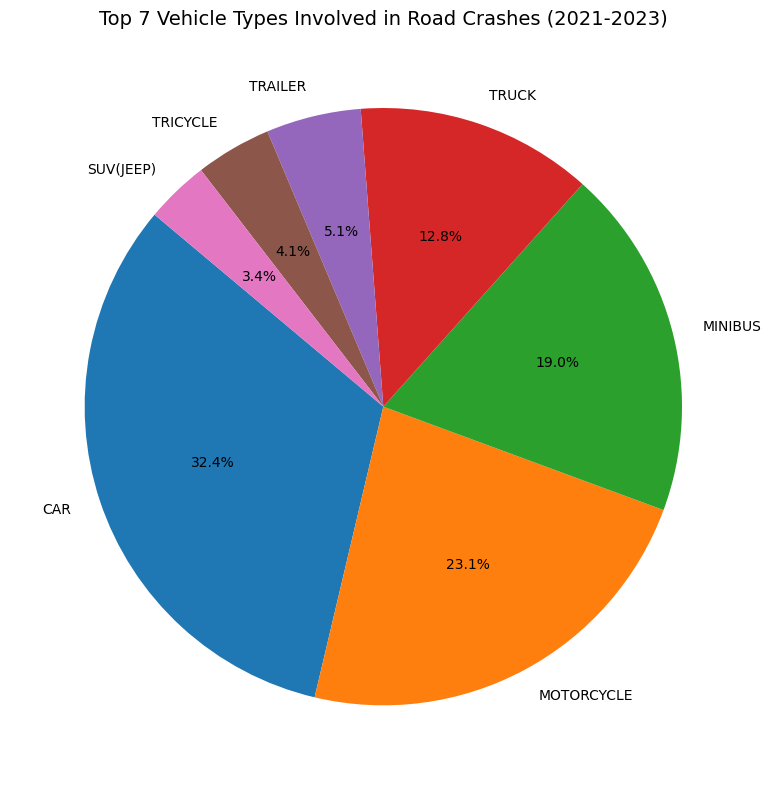

In [19]:
# Select top 7 vehicle types 
top7_vehicles = vehicle_totals_num.head(7)

# Pie chart with automatic colors
plt.figure(figsize=(8,8))

plt.pie(
    top7_vehicles["Year_Total"],                 # Values
    labels=top7_vehicles["VEHICLE CATEGORY"],    # Labels
    autopct='%1.1f%%',                           # Show percentages
    startangle=140                               # Start angle for better visual
    # colors argument removed to use default automatic colors
)

plt.title("Top 7 Vehicle Types Involved in Road Crashes (2021-2023)", fontsize=14)
plt.tight_layout()
plt.show()


In [20]:
# Which vehicle categories contribute most to crash involvement in Nigeria?
# Vehicle categories involved in Road Crashes from 2021 to 2023 across all quarters
dfs = []
main_categories = ["GOVERNMENT", "PRIVATE", "COMMERCIAL", "DIPLOMAT"]

for sheet, df in df_dict.items():
    if sheet.startswith("VehCat"):
        # Clean category names
        df["VEHICLE CATEGORY"] = df["VEHICLE CATEGORY"].astype(str).str.strip().str.upper()

        # Keep only the main categories
        df = df[df["VEHICLE CATEGORY"].isin(main_categories)].copy()

        # Identify quarterly columns (CATEG_NUM...)
        categ_cols = [c for c in df.columns if c.startswith("CATEG_NUM")]

        # Convert to numeric, ignore errors
        df[categ_cols] = df[categ_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

        # Calculate yearly total per category (sum across the quarterly columns)
        df["Year_Total"] = df[categ_cols].sum(axis=1)

        # Keep only category and yearly total
        dfs.append(df[["VEHICLE CATEGORY", "Year_Total"]])

# Combine all years
combined_df = pd.concat(dfs, ignore_index=True)

# Sum across all years by category
vehicle_totals = combined_df.groupby("VEHICLE CATEGORY", as_index=False)["Year_Total"].sum()

# Optional: sort descending
vehicle_totals = vehicle_totals.sort_values("Year_Total", ascending=False).reset_index(drop=True)

print(vehicle_totals)


  VEHICLE CATEGORY  Year_Total
0       COMMERCIAL     38864.0
1          PRIVATE     18771.0
2       GOVERNMENT       628.0
3         DIPLOMAT        16.0


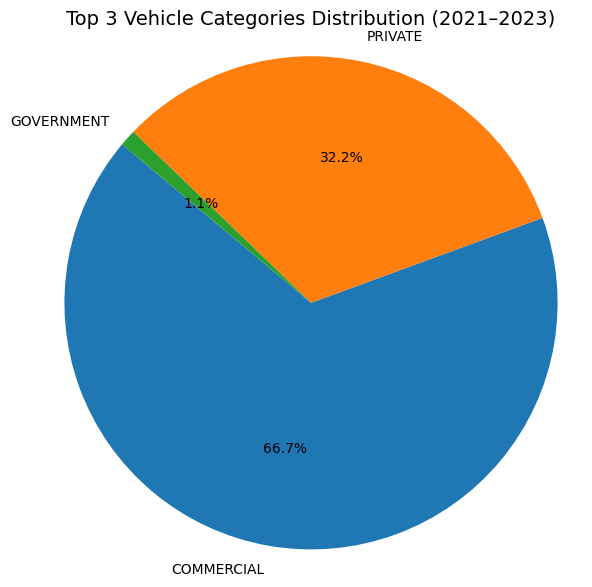

In [21]:
# Visualization: Pie chart for top 3 categories
top3 = vehicle_totals.head(3)

plt.figure(figsize=(7, 7))
plt.pie(
    top3["Year_Total"],
    labels=top3["VEHICLE CATEGORY"],
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Top 3 Vehicle Categories Distribution (2021–2023)", fontsize=14)
plt.axis("equal")  # keeps the pie circular
plt.show()

## Vehicle Categories Involved in Crashes

Vehicle involvement in road traffic crashes was analyzed by aggregating crash records across vehicle categories over the study period.

The analysis highlights:
- Which vehicle types are most frequently involved in crashes
- The relative contribution of private, commercial, and government vehicles
- Patterns that may reflect exposure, usage intensity, or regulatory compliance

This information is critical for targeted vehicle safety regulations and enforcement strategies.


## Summary of Key Findings

The analysis of road traffic crash data in Nigeria from 2021 to 2023 reveals several important insights:

- Road traffic crashes exhibit noticeable temporal variation across quarters.
- A small number of states account for a disproportionately high number of crash cases, indicating clear spatial hotspots.
- Certain crash causes dominate across all years, suggesting persistent behavioral and systemic risk factors.
- Commercial and private vehicles are more frequently involved in crashes compared to other vehicle categories.
- Males account for a higher proportion of both injuries and fatalities than females.

These findings underscore the need for targeted, data-driven road safety policies focused on high-risk periods, locations, and road user groups.
